In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import plotly.express as px

In [209]:
df = pd.read_csv("investments_VC.csv", encoding="latin1")

df

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [210]:
#retirar colunas irrelevantes#
irrelevant_col = ['permalink', 'homepage_url', 'state_code', 'region', 'founded_month', 'founded_quarter', 'founded_year']
df.drop(columns = irrelevant_col, inplace = True)

In [211]:
initial_rows = len(df)

# Remove rows where ALL values are missing
df.dropna(how='all', inplace=True)

print(f"Rows removed: {initial_rows - len(df)}")

Rows removed: 4856


In [212]:
lista_para_analise = df.select_dtypes(include=['number']).columns.tolist()

# Calcular métricas
total_rows = len(df)
non_zero_counts = (df[lista_para_analise] != 0).sum()
zero_percentages = (df[lista_para_analise] == 0).mean() * 100

# 5. Criar a Tabela de Resumo
summary_df = pd.DataFrame({
    'Coluna': lista_para_analise,
    'Zeros (%)': zero_percentages.map('{:.1f}%'.format),
    'Empresas com valor': non_zero_counts.values
})

# Função para definir a Conclusão baseada nos limites (thresholds)
def definir_conclusao(pct):
    if pct > 99.5: return "Descartável (Ruído puro)"
    if pct > 98.5: return "Candidata a Drop"
    if pct > 95.0: return "Limite (Ainda relevante)"
    return "Útil (Bom volume de dados)"

summary_df['Conclusão'] = zero_percentages.apply(definir_conclusao).values

# Exibir o resultado final
print("TABELA DE ANÁLISE DE VARIÂNCIA (ROUNDS)")
print("-" * 75)
print(summary_df.to_string(index=False))

TABELA DE ANÁLISE DE VARIÂNCIA (ROUNDS)
---------------------------------------------------------------------------
              Coluna Zeros (%)  Empresas com valor                  Conclusão
      funding_rounds      0.0%               49438 Útil (Bom volume de dados)
                seed     72.0%               13840 Útil (Bom volume de dados)
             venture     52.9%               23277 Útil (Bom volume de dados)
 equity_crowdfunding     98.9%                 522           Candidata a Drop
         undisclosed     98.1%                 952   Limite (Ainda relevante)
    convertible_note     98.9%                 557           Candidata a Drop
      debt_financing     91.5%                4225 Útil (Bom volume de dados)
               angel     93.7%                3129 Útil (Bom volume de dados)
               grant     97.7%                1142   Limite (Ainda relevante)
      private_equity     97.2%                1373   Limite (Ainda relevante)
     post_ipo_equity     9

In [213]:

# 3. Criar o Stage Level usando TODOS os rounds (do mais alto para o mais baixo)
def get_full_stage(row):
    if row['round_H'] > 0: return 8
    if row['round_G'] > 0: return 7
    if row['round_F'] > 0: return 6
    if row['round_E'] > 0: return 5
    if row['round_D'] > 0: return 4
    if row['round_C'] > 0: return 3
    if row['round_B'] > 0: return 2
    if row['round_A'] > 0: return 1
    return 0

df['stage_level'] = df.apply(get_full_stage, axis=1)

# Lista de ELIMINAÇÃO 
cols_to_remove = [
    'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

df.drop(columns=[c for c in cols_to_remove if c in df.columns], inplace=True)

print(f"Dataset reduzido para {df.shape[1]} colunas.")
print("A trajetória de todas as empresas foi salva na coluna 'stage_level'.")

Dataset reduzido para 25 colunas.
A trajetória de todas as empresas foi salva na coluna 'stage_level'.


In [214]:

ZERO_THRESHOLD = 0.98  # Drop columns with more than 98% zeros
NULL_THRESHOLD = 0.90  # Drop columns with more than 90% missing values

# Identify columns with too many Zeros
zero_ratio = (df == 0).sum() / len(df)
cols_to_drop_zeros = zero_ratio[zero_ratio > ZERO_THRESHOLD].index.tolist()

# Identify columns with too many Nulls (NaN)
null_ratio = df.isnull().sum() / len(df)
cols_to_drop_nulls = null_ratio[null_ratio > NULL_THRESHOLD].index.tolist()

all_cols_to_drop = list(set(cols_to_drop_zeros + cols_to_drop_nulls))

# DROP
all_cols_to_drop = list(set(cols_to_drop_zeros + cols_to_drop_nulls))

print(f"Dropping {len(cols_to_drop_zeros)} columns due to Zeros: {cols_to_drop_zeros}")
print(f"Dropping {len(cols_to_drop_nulls)} columns due to Nulls: {cols_to_drop_nulls}")

df.drop(columns=all_cols_to_drop, inplace=True)

print("Dataset simplified and saved successfully.")


Dropping 7 columns due to Zeros: ['equity_crowdfunding', 'undisclosed', 'convertible_note', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
Dropping 0 columns due to Nulls: []
Dataset simplified and saved successfully.


In [215]:
df.shape

(49438, 18)

In [216]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 49438 entries, 0 to 49437
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 49437 non-null  object 
 1   category_list        45477 non-null  object 
 2    market              45470 non-null  object 
 3    funding_total_usd   49438 non-null  object 
 4   status               48124 non-null  object 
 5   country_code         44165 non-null  object 
 6   city                 43322 non-null  object 
 7   funding_rounds       49438 non-null  float64
 8   founded_at           38554 non-null  object 
 9   first_funding_at     49438 non-null  object 
 10  last_funding_at      49438 non-null  object 
 11  seed                 49438 non-null  float64
 12  venture              49438 non-null  float64
 13  debt_financing       49438 non-null  float64
 14  angel                49438 non-null  float64
 15  grant                49438 non-null  floa

In [217]:
df.describe()

,funding_rounds,seed,venture,debt_financing,angel,grant,private_equity,stage_level
count,49438.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,49438.000000
mean,1.696205,2.173215e+05,7.501051e+06,1.888157e+06,6.541898e+04,1.628453e+05,2.074286e+06,0.517557
std,1.294213,1.056985e+06,2.847112e+07,1.382046e+08,6.582908e+05,5.612088e+06,3.167231e+07,1.068163
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,2.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,18.000000,1.300000e+08,2.351000e+09,3.007950e+10,6.359026e+07,7.505000e+08,3.500000e+09,8.000000


In [218]:
# 1. Limpar a coluna 'funding_total_usd' (Transformar texto em número real)
# Note que o nome da coluna no seu CSV tem espaços: ' funding_total_usd '
df[' funding_total_usd '] = df[' funding_total_usd '].str.replace(',', '') # Tira as vírgulas
df[' funding_total_usd '] = pd.to_numeric(df[' funding_total_usd '], errors='coerce') # Vira número

# Tratar o Status (Operating, Acquired, Closed)
# Como são poucos valores, vamos transformar em Categoria para economizar RAM
df['status'] = df['status'].astype('category')

# Remover linhas onde o nome da empresa é nulo (Não servem para nada)
df.dropna(subset=['name'], inplace=True)

In [219]:
print(df.isnull().sum())


name                       0
category_list           3961
 market                 3968
 funding_total_usd      8531
status                  1314
country_code            5272
city                    6115
funding_rounds             0
founded_at             10884
first_funding_at           0
last_funding_at            0
seed                       0
venture                    0
debt_financing             0
angel                      0
grant                      0
private_equity             0
stage_level                0
dtype: int64


In [220]:
df

,name,category_list,market,funding_total_usd,status,country_code,city,funding_rounds,founded_at,first_funding_at,last_funding_at,seed,venture,debt_financing,angel,grant,private_equity,stage_level
0,#waywire,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,New York,1.0,2012-06-01,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0
1,&TV Communications,|Games|,Games,4000000.0,operating,USA,Los Angeles,2.0,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,40000.0,operating,EST,Tallinn,1.0,2012-10-26,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0
3,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,London,1.0,2011-04-01,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0
4,-R- Ranch and Mine,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,Fort Worth,2.0,2014-01-01,2014-08-17,2014-09-26,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49433,Zzish,|Analytics|Gamification|Developer APIs|iOS|And...,Education,320000.0,operating,GBR,London,1.0,2013-01-28,2014-03-24,2014-03-24,320000.0,0.0,0.0,0.0,0.0,0.0,0
49434,ZZNode Science and Technology,|Enterprise Software|,Enterprise Software,1587301.0,operating,CHN,Beijing,1.0,NaN,2012-04-01,2012-04-01,0.0,1587301.0,0.0,0.0,0.0,0.0,1
49435,Zzzzapp Wireless ltd.,|Web Development|Advertising|Wireless|Mobile|,Web Development,97398.0,operating,HRV,Split,5.0,2012-05-13,2011-11-01,2014-09-10,71525.0,0.0,0.0,0.0,0.0,0.0,0
49436,[a]list games,|Games|,Games,9300000.0,operating,NaN,NaN,1.0,NaN,2011-11-21,2011-11-21,9300000.0,0.0,0.0,0.0,0.0,0.0,0


In [221]:
# Remover linhas duplicadas
rows_before = len(df)
df.drop_duplicates(inplace=True)
rows_after = len(df)

print(f"Linhas removidas por duplicação: {rows_before - rows_after}")
print(f"Shape final: {df.shape}")
print(f"Total de registros únicos: {rows_after}")

Linhas removidas por duplicação: 0
Shape final: (49437, 18)
Total de registros únicos: 49437


In [222]:
# Obter todas as colunas numéricas
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

print(f"Total de variáveis numéricas: {len(numeric_columns)}")
print(f"Variáveis: {numeric_columns}")

df_numeric = df[numeric_columns]

Total de variáveis numéricas: 9
Variáveis: [' funding_total_usd ', 'funding_rounds', 'seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity', 'stage_level']


In [223]:
df_numeric.var()

 funding_total_usd     2.845323e+16
funding_rounds         1.675011e+00
seed                   1.117239e+12
venture                8.106202e+14
debt_financing         1.910089e+16
angel                  4.333554e+11
grant                  3.149617e+13
private_equity         1.003156e+15
stage_level            1.140990e+00
dtype: float64

In [224]:

df.columns = df.columns.str.strip()
xy = len(df)
print(f"Linhas originais: {len(df)}")
# Remover linhas onde 'funding_total_usd' OU 'market' são nulos
# Estas são as colunas vitais para definir o perfil da startup
df.dropna(subset=['funding_total_usd', 'market'], inplace=True)

print(f"Linhas removidas: {xy - len(df)}")
print(f"Linhas restantes: {len(df)}")

Linhas originais: 49437
Linhas removidas: 11039
Linhas restantes: 38398


In [225]:
zero_pct = (df == 0).mean() * 100
print("Percentage of zeros in each feature:")
print(zero_pct.round(2))

# Check rows with all zeros in funding types
funding_cols = ['seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity']
all_zero_funding = (df[funding_cols] == 0).all(axis=1)
print(f"\nRows with all zero funding types: {all_zero_funding.sum()} out of {len(df)} ({all_zero_funding.mean()*100:.2f}%)")

# Rows with zero in venture (main funding)
zero_venture = (df['venture'] == 0)
print(f"Rows with zero venture funding: {zero_venture.sum()} ({zero_venture.mean()*100:.2f}%)")

all_zero_funding = (df[funding_cols] == 0).all(axis=1)
df = df[~all_zero_funding]

Percentage of zeros in each feature:
name                  0.00
category_list         0.00
market                0.00
funding_total_usd     0.00
status                0.00
country_code          0.00
city                  0.00
funding_rounds        0.00
founded_at            0.00
first_funding_at      0.00
last_funding_at       0.00
seed                 66.67
venture              41.82
debt_financing       89.56
angel                92.05
grant                97.29
private_equity       96.59
stage_level          67.46
dtype: float64

Rows with all zero funding types: 1467 out of 38398 (3.82%)
Rows with zero venture funding: 16057 (41.82%)


for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_numeric[col], bins=30, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

In [226]:
# 1. Combine similar funding types BEFORE the log transformation
df['early_stage_funding'] = df['seed'] + df['angel'] + df['grant']

# Now you can drop the highly sparse original columns
df.drop(columns=['seed', 'angel', 'grant'], inplace=True)

C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\3611892420.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\3611892420.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [227]:
funding_type_cols = [
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity'
]

# Avoid division by zero
total_funding_safe = df['funding_total_usd'].replace(0, np.nan)

for col in funding_type_cols:
    df[f'{col}_ratio'] = df[col] / total_funding_safe

# Replace NaN values with 0
# This means: if total funding is zero or unavailable, the ratio is treated as 0
ratio_cols = [f'{col}_ratio' for col in funding_type_cols]
df[ratio_cols] = df[ratio_cols].fillna(0)

# Optional: cap ratios at 1 in case some funding-type values exceed total funding
# due to inconsistencies in the dataset
df[ratio_cols] = df[ratio_cols].clip(lower=0, upper=1)

print("Funding ratios created:")
display(df[ratio_cols].head())

Funding ratios created:


C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\566078729.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\566078729.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\566078729.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

,early_stage_funding_ratio,venture_ratio,debt_financing_ratio,private_equity_ratio
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
5,0.0,1.0,0.0,0.0


In [228]:
columns_to_log = [
    'funding_total_usd', 
    'funding_rounds', 
    'early_stage_funding', 
    'venture', 
    'debt_financing', 
    'private_equity'
]

# 2. Apply the log1p transformation and save them as new columns 
# (Adding the 'log_' prefix keeps your data organized)
for col in columns_to_log:
    df[f'log_{col}'] = np.log1p(df[col])

# View the original vs the log-transformed data to see the difference
print("Transformation successful. Here is a sample of 'venture' vs 'log_venture':")
print(df[['venture', 'log_venture']].head())

Transformation successful. Here is a sample of 'venture' vs 'log_venture':
     venture  log_venture
0        0.0     0.000000
1  4000000.0    15.201805
2        0.0     0.000000
3        0.0     0.000000
5  7000000.0    15.761421


C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\1078748937.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\1078748937.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\1078748937.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [229]:
features_to_scale = [
    'log_funding_total_usd', 
    'log_funding_rounds', 
    'log_early_stage_funding', 
    'log_venture', 
    'log_debt_financing',
    'log_private_equity', 
    'stage_level',

    # Funding composition ratios
    'early_stage_funding_ratio',
    'venture_ratio',
    'debt_financing_ratio',
    'private_equity_ratio'
]
# 2. Create a copy of your dataframe to keep things clean
df_clustering = df.dropna(subset=features_to_scale).copy()

# 3. Initialize the Scaler
scaler = RobustScaler()

# 4. Fit and Transform the data
scaled_arrays = scaler.fit_transform(df_clustering[features_to_scale])

# 5. Convert back to a Pandas DataFrame for easier viewing and EDA
df_scaled = pd.DataFrame(
    scaled_arrays, 
    columns=features_to_scale, 
    index=df_clustering.index
)

# View the scaled data
print("Shape of scaled data:", df_scaled.shape)
df_scaled.head()

Shape of scaled data: (36931, 11)


,log_funding_total_usd,log_funding_rounds,log_early_stage_funding,log_venture,log_debt_financing,log_private_equity,stage_level,early_stage_funding_ratio,venture_ratio,debt_financing_ratio,private_equity_ratio
0,-0.079099,0.0,1.146109,-0.868580,0.0,0.0,0.0,1.0,-0.857584,0.0,0.0
1,0.185786,1.0,0.000000,0.087156,0.0,0.0,0.0,0.0,0.142416,0.0,0.0
2,-1.289800,0.0,0.844857,-0.868580,0.0,0.0,0.0,1.0,-0.857584,0.0,0.0
3,-0.128492,0.0,1.133819,-0.868580,0.0,0.0,0.0,1.0,-0.857584,0.0,0.0
5,0.365099,0.0,0.000000,0.122339,0.0,0.0,2.0,0.0,0.142416,0.0,0.0


In [230]:
# 1. Define the informational columns you want to keep for your App and EDA
# These are the columns that describe the startup but aren't used for the math
info_columns = [
    'name', 
    'category_list', 
    'market', 
    'status', 
    'country_code', 
    'city'
]

# 2. Extract these columns from the dataframe we used for clustering
# We use df_clustering so the indexes match perfectly with df_scaled
df_info = df_clustering[info_columns]

# 3. Combine the informational columns with the scaled numerical columns
# axis=1 means we are joining them side-by-side (column-wise)
df_final = pd.concat([df_info, df_scaled], axis=1)

# 4. View the final dataset ready for K-Means!
print(f"Final Dataset Shape: {df_final.shape}")
display(df_final.head())

Final Dataset Shape: (36931, 17)


,name,category_list,market,status,country_code,city,log_funding_total_usd,log_funding_rounds,log_early_stage_funding,log_venture,log_debt_financing,log_private_equity,stage_level,early_stage_funding_ratio,venture_ratio,debt_financing_ratio,private_equity_ratio
0,#waywire,|Entertainment|Politics|Social Media|News|,News,acquired,USA,New York,-0.079099,0.0,1.146109,-0.868580,0.0,0.0,0.0,1.0,-0.857584,0.0,0.0
1,&TV Communications,|Games|,Games,operating,USA,Los Angeles,0.185786,1.0,0.000000,0.087156,0.0,0.0,0.0,0.0,0.142416,0.0,0.0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,operating,EST,Tallinn,-1.289800,0.0,0.844857,-0.868580,0.0,0.0,0.0,1.0,-0.857584,0.0,0.0
3,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,operating,GBR,London,-0.128492,0.0,1.133819,-0.868580,0.0,0.0,0.0,1.0,-0.857584,0.0,0.0
5,.Club Domains,|Software|,Software,NaN,USA,Oakland Park,0.365099,0.0,0.000000,0.122339,0.0,0.0,2.0,0.0,0.142416,0.0,0.0


Text(0, 0.5, 'Cumulative Variance')

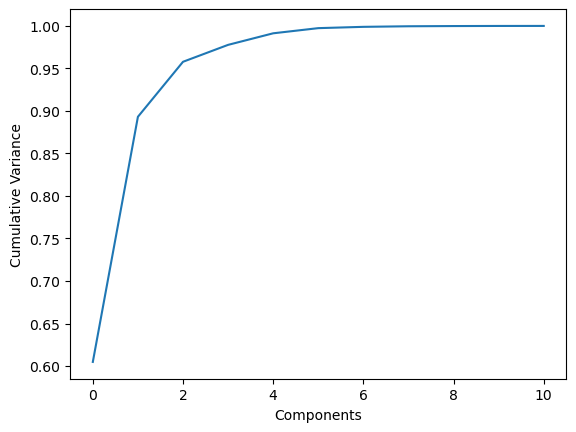

In [231]:
pca_full = PCA()
pca_full.fit(df_scaled)

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Components')
plt.ylabel('Cumulative Variance')

In [232]:
# 1. Initialize PCA to keep 3 components (great for 3D App visualizations later)
pca = PCA(n_components=3)

# 2. Fit and transform your SCALED data
# df_scaled is the output from your RobustScaler
pca_components = pca.fit_transform(df_scaled)

# 3. Create a new dataframe with the dense, non-zero components
df_pca = pd.DataFrame(
    data=pca_components, 
    columns=['PC1', 'PC2', 'PC3'],
    index=df_scaled.index
)

# View how much "information" (variance) these 3 columns captured
print(f"Variance explained by 3 components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Variance explained by 3 components: 95.78%


In [233]:
%%script false --no-raise
inertia = []
silhouette_scores = []
K_range = range(2, 10) # Testing 2 to 9 clusters

for k in K_range:
    # Initialize K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    
    # Calculate Inertia (Elbow Method)
    inertia.append(kmeans.inertia_)
    
    # Calculate Silhouette Score
    score = silhouette_score(df_pca, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia (Look for the "elbow" or bend)
ax1.plot(K_range, inertia, 'bo-', label='Inertia (WCSS)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params('y', colors='b')

# Plot Silhouette Score (Look for the highest peak)
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('Elbow Method and Silhouette Score for Optimal K')
plt.show()

Couldn't find program: 'false'


In [234]:
df_pca

,PC1,PC2,PC3
0,-1.660168,-0.540303,-1.162895
1,-1.534363,-0.486003,0.134291
2,-1.694526,-0.602639,-1.548936
3,-1.661570,-0.542846,-1.178644
5,-1.547107,-0.486698,1.292383
...,...,...,...
49433,-1.675618,-0.568333,-1.336485
49434,-1.589816,-0.520283,0.360846
49435,-1.485941,-0.512769,-0.340078
49436,-1.644979,-0.512745,-0.992233


In [235]:

# Assuming you chose K=4 (change this if your charts suggest otherwise)
OPTIMAL_K = 4

# Run the final model
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init = 10)
cluster_labels = final_kmeans.fit_predict(df_pca)

df2 = df['Cluster'] = cluster_labels.copy()
df_final['Cluster'] = cluster_labels # df_final is from our previous step with the names/markets

print("Clustering Complete! Startups per cluster:")
print(df_final['Cluster'].value_counts())

Clustering Complete! Startups per cluster:
Cluster
0    24102
3     7705
1     3819
2     1305
Name: count, dtype: int64


C:\Users\pedro\AppData\Local\Temp\ipykernel_8780\911654524.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [236]:
print(df_pca.columns)

Index(['PC1', 'PC2', 'PC3'], dtype='object')


In [237]:


# Create a 3D scatter plot using the 3 Principal Components
fig = px.scatter_3d(
    df_pca, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color=df_final['Cluster'].astype(str), # Color by cluster
    hover_name=df_final['name'],         # Show startup name on hover
    hover_data={'market': df_final['market']}, # Show market on hover
    title="Startup Clustering: 3D PCA Market Landscape",
    opacity=0.7
)

# Make the layout look clean for an app
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

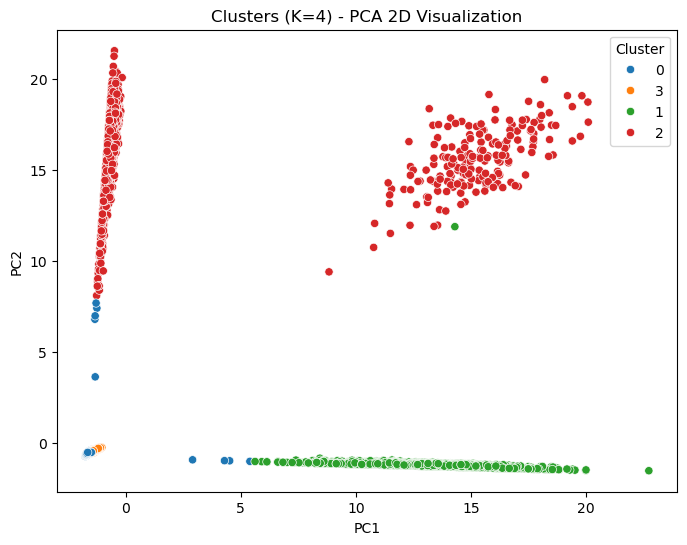

In [238]:
pca_2 = PCA(n_components=2)
df_pca_2 = pca_2.fit_transform(df_scaled)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_pca_2[:,0],
    y=df_pca_2[:,1],
    hue=df_final['Cluster'].astype(str),
    palette='tab10'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters (K=4) - PCA 2D Visualization')
plt.show()

In [239]:
OPTIMAL_K = 4

kmeans_scaled = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    random_state=42,
    n_init=10
)

cluster_labels_scaled = kmeans_scaled.fit_predict(df_scaled)

# Add labels to final dataframe
df_final['Cluster_scaled'] = cluster_labels_scaled

print("K-Means on df_scaled complete!")
print("Startups per cluster:")
print(df_final['Cluster_scaled'].value_counts().sort_index())

K-Means on df_scaled complete!
Startups per cluster:
Cluster_scaled
0    24576
1     3819
2     1305
3     7231
Name: count, dtype: int64


In [240]:
# ------------------------------------------------------------
# 2. PCA 2D only for visualization
# ------------------------------------------------------------

pca_vis = PCA(n_components=2)
df_scaled_pca_2d = pca_vis.fit_transform(df_scaled)

df_scaled_pca_2d = pd.DataFrame(
    df_scaled_pca_2d,
    columns=['PC1', 'PC2'],
    index=df_final.index
)

df_scaled_pca_2d['Cluster'] = cluster_labels_scaled.astype(str)

print("Explained variance by 2D PCA:")
print(pca_vis.explained_variance_ratio_)
print("Cumulative explained variance:")
print(pca_vis.explained_variance_ratio_.sum())

Explained variance by 2D PCA:
[0.60482965 0.28830845]
Cumulative explained variance:
0.8931380996009699


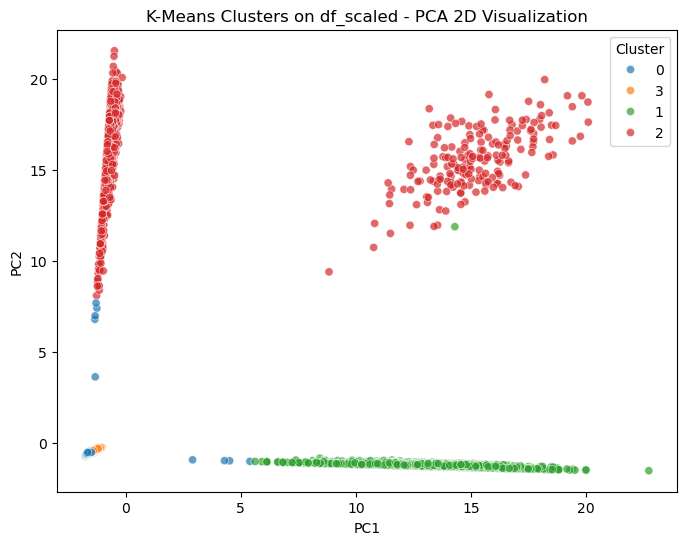

In [241]:
# ------------------------------------------------------------
# 3. 2D visualization of K-Means on df_scaled
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_scaled_pca_2d,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.7,
    s=35
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on df_scaled - PCA 2D Visualization')
plt.legend(title='Cluster')
plt.show()

In [242]:
print("K-Means on df_scaled:")
print(df_final['Cluster_scaled'].value_counts().sort_index())

print("\nK-Means on df_pca:")
print(df_final['Cluster'].value_counts().sort_index())

K-Means on df_scaled:
Cluster_scaled
0    24576
1     3819
2     1305
3     7231
Name: count, dtype: int64

K-Means on df_pca:
Cluster
0    24102
1     3819
2     1305
3     7705
Name: count, dtype: int64


In [243]:
df_profile_real = df_clustering.copy()
df_profile_real['Cluster'] = df_final['Cluster'].values

df_profile_real.to_csv("clustered_startups_real_values.csv", index=False)